In [6]:
import pandas as pd

# Just load Q1 first — don't load all 4 yet, we want to understand structure before committing
df_q1 = pd.read_excel("../data/raw/LCA_Disclosure_Data_FY2025_Q1.xlsx")

print("Shape:", df_q1.shape)
print("\nColumns:")
print(df_q1.columns.tolist())

Shape: (107414, 97)

Columns:
['CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DECISION_DATE', 'ORIGINAL_CERT_DATE', 'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE', 'SOC_TITLE', 'FULL_TIME_POSITION', 'BEGIN_DATE', 'END_DATE', 'TOTAL_WORKER_POSITIONS', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT', 'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT', 'CHANGE_EMPLOYER', 'AMENDED_PETITION', 'EMPLOYER_NAME', 'TRADE_NAME_DBA', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2', 'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_POSTAL_CODE', 'EMPLOYER_COUNTRY', 'EMPLOYER_PROVINCE', 'EMPLOYER_PHONE', 'EMPLOYER_PHONE_EXT', 'EMPLOYER_FEIN', 'NAICS_CODE', 'EMPLOYER_POC_LAST_NAME', 'EMPLOYER_POC_FIRST_NAME', 'EMPLOYER_POC_MIDDLE_NAME', 'EMPLOYER_POC_JOB_TITLE', 'EMPLOYER_POC_ADDRESS1', 'EMPLOYER_POC_ADDRESS2', 'EMPLOYER_POC_CITY', 'EMPLOYER_POC_STATE', 'EMPLOYER_POC_POSTAL_CODE', 'EMPLOYER_POC_COUNTRY', 'EMPLOYER_POC_PROVINCE', 'EMPLOYER_POC_PHONE', 'EMPLOYER_POC_PHONE_EXT', 'EMPLOYER_POC_EMAIL', 'AGENT_REPRESENTING_EM

In [7]:
# Only the columns we actually need for this project
cols_needed = [
    "CASE_NUMBER", "CASE_STATUS", "VISA_CLASS", "RECEIVED_DATE", "DECISION_DATE",
    "JOB_TITLE", "SOC_CODE", "SOC_TITLE", "FULL_TIME_POSITION",
    "EMPLOYER_NAME", "EMPLOYER_STATE", "NAICS_CODE",
    "WORKSITE_CITY", "WORKSITE_STATE",
    "WAGE_RATE_OF_PAY_FROM", "WAGE_RATE_OF_PAY_TO", "WAGE_UNIT_OF_PAY",
    "PREVAILING_WAGE", "PW_UNIT_OF_PAY", "PW_WAGE_LEVEL"
]

# Trim Q1 down right now, since it's already loaded in memory
df_q1_trimmed = df_q1[cols_needed].copy()

print(df_q1_trimmed.shape)
df_q1_trimmed.head()

(107414, 20)


,CASE_NUMBER,CASE_STATUS,VISA_CLASS,RECEIVED_DATE,DECISION_DATE,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,EMPLOYER_NAME,EMPLOYER_STATE,NAICS_CODE,WORKSITE_CITY,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_WAGE_LEVEL
0,I-200-24366-578757,Withdrawn,H-1B,2024-12-31,2024-12-31,Database Administrator,15-1242.00,Database Administrators,N,"FIRST TEK, INC.",NJ,541511,Mountain House,CA,42.53,65.0,Hour,42.53,Hour,II
1,I-200-24366-578499,Withdrawn,H-1B,2024-12-31,2024-12-31,Abdominal Radiologist Assistant Professor Clin...,29-1224.00,Radiologists,Y,University of Utah Office of General Counsel,UT,611310,Salt Lake City,UT,377795.00,NaN,Year,134347.00,Year,II
2,I-200-24366-578081,Withdrawn,H-1B,2024-12-31,2024-12-31,PROJECT MANAGER,15-1299.09,Information Technology Project Managers,Y,CYBAGE SOFTWARE INC,NJ,5416,EDISON,NJ,111800.00,NaN,Year,90002.00,Year,II
3,I-200-24366-578384,Withdrawn,H-1B,2024-12-31,2024-12-31,Database Administrators,15-1242.00,Database Administrators,Y,L&T Technology Services Limited,NJ,541330,Gregory,TX,79622.00,89622.0,Year,69326.00,Year,II
4,I-200-24366-578405,Withdrawn,H-1B,2024-12-31,2024-12-31,Computer Systems Analyst,15-1211.00,Computer Systems Analysts,Y,"TECH MAHINDRA (AMERICAS), INC",NJ,541511,IRVING,TX,121250.00,NaN,Year,100714.00,Year,II


In [8]:
import time

quarters = ["Q1", "Q2", "Q3", "Q4"]
dfs = []

for q in quarters:
    start = time.time()
    print(f"Loading {q}...")
    df_raw = pd.read_excel(f"../data/raw/LCA_Disclosure_Data_FY2025_{q}.xlsx")
    df_trimmed = df_raw[cols_needed].copy()
    df_trimmed["FISCAL_QUARTER"] = q  # tag which quarter each row came from
    dfs.append(df_trimmed)
    del df_raw  # free up memory immediately, we don't need the full 97-column version anymore
    print(f"  {q} done in {time.time()-start:.0f}s — shape {df_trimmed.shape}")

df_all = pd.concat(dfs, ignore_index=True)
print("\nFinal combined shape:", df_all.shape)

Loading Q1...
  Q1 done in 55s — shape (107414, 21)
Loading Q2...
  Q2 done in 36s — shape (132133, 21)
Loading Q3...
  Q3 done in 71s — shape (238425, 21)
Loading Q4...
  Q4 done in 42s — shape (118580, 21)

Final combined shape: (596552, 21)


In [12]:
!pip install pyarrow --quiet

In [14]:
# Find rows where WORKSITE_CITY is not a string
mask = df_all["WORKSITE_CITY"].apply(lambda x: not isinstance(x, str) and pd.notna(x))
print("Number of bad rows:", mask.sum())
df_all.loc[mask, ["CASE_NUMBER", "WORKSITE_CITY", "EMPLOYER_NAME"]].head(10)

Number of bad rows: 22


,CASE_NUMBER,WORKSITE_CITY,EMPLOYER_NAME
4031,I-200-24354-559364,0,"Washington State Department of Children, Youth..."
38729,I-200-24325-489348,29615,"Global Technical Training Services, Inc."
41955,I-200-24324-483627,75024,"Redeemsoft, LLC"
162687,I-200-25051-711873,10016,ZMO Law PLLC
257201,I-200-25167-097842,100,"PubNub, Inc."
274435,I-200-25161-074774,7070,"RANDSTAD DIGITAL, LLC"
275006,I-200-25161-073348,66214,KSOFT SYSTEMS INC
281315,I-200-25159-066109,94607,INFOSYS LIMITED
314378,I-200-25148-026779,200,Renesas Electronics America Inc.
318683,I-200-25146-017387,33065,"Fiserv Solutions, LLC"


In [15]:
# Force WORKSITE_CITY to be a clean string column.
# Any value that isn't actually text (e.g. these 22 stray zip codes / numbers) becomes "UNKNOWN"
df_all["WORKSITE_CITY"] = df_all["WORKSITE_CITY"].apply(
    lambda x: x if isinstance(x, str) else "UNKNOWN"
)

# Confirm the fix worked
print(df_all["WORKSITE_CITY"].apply(lambda x: not isinstance(x, str)).sum(), "non-string values remaining")

0 non-string values remaining


In [17]:
text_cols = ["CASE_NUMBER", "CASE_STATUS", "VISA_CLASS", "JOB_TITLE", "SOC_CODE", "SOC_TITLE",
             "FULL_TIME_POSITION", "EMPLOYER_NAME", "EMPLOYER_STATE", "WORKSITE_CITY",
             "WORKSITE_STATE", "PW_UNIT_OF_PAY", "PW_WAGE_LEVEL", "WAGE_UNIT_OF_PAY", "FISCAL_QUARTER"]

for col in text_cols:
    bad = df_all[col].apply(lambda x: not isinstance(x, str) and pd.notna(x)).sum()
    if bad > 0:
        print(f"{col}: {bad} non-string values")

In [18]:
df_all.to_parquet("../data/processed/lca_fy2025_trimmed.parquet", index=False)
print("Saved.")

Saved.


In [19]:
import time
start = time.time()
df_check = pd.read_parquet("../data/processed/lca_fy2025_trimmed.parquet")
print(f"Loaded in {time.time()-start:.2f}s, shape: {df_check.shape}")

Loaded in 1.63s, shape: (596552, 21)


In [20]:
df_all["SOC_TITLE"].value_counts().head(30)

SOC_TITLE
Software Developers                                   181867
Computer Systems Engineers/Architects                  26156
Information Technology Project Managers                20623
Software Quality Assurance Analysts and Testers        19724
Data Scientists                                        19603
Computer Programmers                                   14376
Computer Systems Analysts                              14024
Computer and Information Systems Managers              13642
Business Intelligence Analysts                         13425
Accountants and Auditors                               10384
Mechanical Engineers                                   10293
Financial and Investment Analysts                       9050
Operations Research Analysts                            8180
Electronics Engineers, Except Computer                  8122
Electrical Engineers                                    7544
Database Administrators                                 7425
Management Ana

In [21]:
data_role_titles = [
    "Data Scientists",
    "Computer and Information Research Scientists",
    "Database Administrators",
    "Database Architects",
    "Business Intelligence Analysts",
    "Statisticians",
    "Operations Research Analysts"
]

df_data_roles = df_all[df_all["SOC_TITLE"].isin(data_role_titles)].copy()
print(df_data_roles.shape)
df_data_roles["SOC_TITLE"].value_counts()

(60249, 21)


SOC_TITLE
Data Scientists                                 19603
Business Intelligence Analysts                  13425
Operations Research Analysts                     8180
Database Administrators                          7425
Computer and Information Research Scientists     4103
Database Architects                              4044
Statisticians                                    3469
Name: count, dtype: int64

In [22]:
df_data_roles["CASE_STATUS"].value_counts()

CASE_STATUS
Certified                56484
Certified - Withdrawn     2617
Withdrawn                  919
Denied                     229
Name: count, dtype: int64

In [23]:
df_clean = df_data_roles[df_data_roles["CASE_STATUS"].isin(["Certified", "Certified - Withdrawn"])].copy()
print(df_clean.shape)
df_clean["CASE_STATUS"].value_counts()

(59101, 21)


CASE_STATUS
Certified                56484
Certified - Withdrawn     2617
Name: count, dtype: int64

In [24]:
df_clean["WAGE_UNIT_OF_PAY"].value_counts()

WAGE_UNIT_OF_PAY
Year         55985
Hour          2998
Month           68
Week            38
Bi-Weekly       12
Name: count, dtype: int64

In [25]:
def to_annual(row):
    rate = row["WAGE_RATE_OF_PAY_FROM"]
    unit = row["WAGE_UNIT_OF_PAY"]
    
    if pd.isna(rate) or pd.isna(unit):
        return None
    
    multipliers = {
        "Year": 1,
        "Hour": 2080,
        "Month": 12,
        "Week": 52,
        "Bi-Weekly": 26
    }
    
    return rate * multipliers.get(unit, None)

df_clean["ANNUAL_WAGE"] = df_clean.apply(to_annual, axis=1)

# Sanity check: any rows where conversion failed (e.g. unrecognized unit, or missing data)
print("Missing ANNUAL_WAGE:", df_clean["ANNUAL_WAGE"].isna().sum())
df_clean[["WAGE_RATE_OF_PAY_FROM", "WAGE_UNIT_OF_PAY", "ANNUAL_WAGE"]].head(10)

Missing ANNUAL_WAGE: 0


,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,ANNUAL_WAGE
32,99029.0,Year,99029.0
39,70000.0,Year,70000.0
41,180730.0,Year,180730.0
71,124322.0,Year,124322.0
95,85000.0,Year,85000.0
101,140000.0,Year,140000.0
106,80000.0,Year,80000.0
114,114670.0,Year,114670.0
134,113734.0,Year,113734.0
135,95000.0,Year,95000.0


In [26]:
df_clean["ANNUAL_WAGE"].describe()

count    5.910100e+04
mean     3.502493e+05
std      7.499740e+06
min      3.440300e+04
25%      9.504000e+04
50%      1.256940e+05
75%      1.602153e+05
max      4.784000e+08
Name: ANNUAL_WAGE, dtype: float64

In [27]:
df_clean.nlargest(15, "ANNUAL_WAGE")[["EMPLOYER_NAME", "JOB_TITLE", "WAGE_RATE_OF_PAY_FROM", "WAGE_UNIT_OF_PAY", "ANNUAL_WAGE"]]

,EMPLOYER_NAME,JOB_TITLE,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,ANNUAL_WAGE
287089,"10x Genomics, Inc.","Associate Director, Global Sales Analytics & I...",230000.00,Hour,478400000.0
1770,Riviera Partners LLC,Staff Data Engineer,195500.00,Hour,406640000.0
492408,"Owner.com, Inc.","Senior Data Scientist, GTM",180000.00,Hour,374400000.0
10983,Deloitte Consulting LLP,Senior Consultant,170300.00,Hour,354224000.0
466245,DIA Associates LLC,Business Intelligence Analyst,165000.00,Hour,343200000.0
43794,Western Alliance Bank,SQL Database Admin,160000.00,Hour,332800000.0
68499,"Tiger Analytics, Inc.",Lead Business Intelligence Analyst,160000.00,Hour,332800000.0
290579,Unity Technologies SF,Data Scientist,160000.00,Hour,332800000.0
122557,"Cisco Systems, Inc.",AI Operations Engineer,159800.00,Hour,332384000.0
219209,"Character Biosciences, Inc.",Senior Data Engineer,158642.00,Hour,329975360.0


In [28]:
suspicious = df_clean[(df_clean["WAGE_UNIT_OF_PAY"] == "Hour") & (df_clean["WAGE_RATE_OF_PAY_FROM"] > 300)]
print("Suspicious 'Hour' rows:", len(suspicious))
print("Total 'Hour' rows:", (df_clean["WAGE_UNIT_OF_PAY"] == "Hour").sum())

Suspicious 'Hour' rows: 54
Total 'Hour' rows: 2998


In [29]:
# Identify the mislabeled rows
mislabeled_mask = (df_clean["WAGE_UNIT_OF_PAY"] == "Hour") & (df_clean["WAGE_RATE_OF_PAY_FROM"] > 300)

# For those rows, the wage rate is already the annual figure — just copy it over directly
df_clean.loc[mislabeled_mask, "ANNUAL_WAGE"] = df_clean.loc[mislabeled_mask, "WAGE_RATE_OF_PAY_FROM"]

# Re-check the distribution
df_clean["ANNUAL_WAGE"].describe()

count    5.910100e+04
mean     1.380523e+05
std      1.873790e+05
min      3.125000e+02
25%      9.503500e+04
50%      1.256320e+05
75%      1.600000e+05
max      1.434420e+07
Name: ANNUAL_WAGE, dtype: float64

In [30]:
print("=== HIGHEST ===")
display(df_clean.nlargest(10, "ANNUAL_WAGE")[["EMPLOYER_NAME", "JOB_TITLE", "WAGE_RATE_OF_PAY_FROM", "WAGE_UNIT_OF_PAY", "ANNUAL_WAGE"]])

print("=== LOWEST ===")
display(df_clean.nsmallest(10, "ANNUAL_WAGE")[["EMPLOYER_NAME", "JOB_TITLE", "WAGE_RATE_OF_PAY_FROM", "WAGE_UNIT_OF_PAY", "ANNUAL_WAGE"]])

=== HIGHEST ===


,EMPLOYER_NAME,JOB_TITLE,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,ANNUAL_WAGE
576293,"Netflix, Inc.",Analytics Engineer,275850.0,Week,14344200.0
12321,"Gartner, Inc.",VP Analyst,196100.0,Week,10197200.0
276983,"SENSE TALENT LABS, INC.",Lead Engineer,190000.0,Week,9880000.0
133131,"Okta, Inc.",Staff Data Scientist,183581.0,Week,9546212.0
139883,CVS Pharmacy Inc.,Lead Data Scientist,171052.7,Week,8894740.4
22232,"DoorDash, Inc.","Software Engineer, Machine Learning",170600.0,Week,8871200.0
516816,"HubSpot, Inc.",Principal Data Analyst,164403.0,Week,8548956.0
102558,Penney OpCo LLC,Technical Architect,163966.0,Week,8526232.0
456699,Penney OpCo LLC,Technical Architect,163966.0,Week,8526232.0
88200,"Abiomed, Inc.",Senior Software Engineer,158700.0,Week,8252400.0


=== LOWEST ===


,EMPLOYER_NAME,JOB_TITLE,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,ANNUAL_WAGE
519487,Amazon.com Services LLC,Amazon Scholar,312.50,Hour,312.5
378443,Life Insurance Company of North America d/b/a ...,GBS Data & Analytics Associate,34403.00,Year,34403.0
406364,"Arch Plastics Packaging, LLC",Data Scientist,34403.00,Year,34403.0
305425,"Actual Reality Technologies, LLC",Data Scientist,42000.00,Year,42000.0
119927,Gada Investment LLC,Operations Research Analyst,20.69,Hour,43035.2
158826,"Campbellsville University, Inc.",Database Support Analyst,43222.00,Year,43222.0
325585,LANSING MARKETING SERVICES CORPORATION,Operations Research Analyst,44000.00,Year,44000.0
28711,Uniquetex LLC,Business Intelligence Analyst,45802.00,Year,45802.0
556767,University of New Mexico,Data Manager,46134.40,Year,46134.4
335084,Finovax Technologies Inc.,Business Intelligence Analyst,22.61,Hour,47028.8


In [31]:
suspicious_week = df_clean[(df_clean["WAGE_UNIT_OF_PAY"] == "Week") & (df_clean["WAGE_RATE_OF_PAY_FROM"] > 10000)]
print("Suspicious 'Week' rows:", len(suspicious_week))
print("Total 'Week' rows:", (df_clean["WAGE_UNIT_OF_PAY"] == "Week").sum())

Suspicious 'Week' rows: 36
Total 'Week' rows: 38


In [32]:
# Same fix pattern: if "Week" but rate is implausibly high for a true weekly wage,
# treat the number as if it were already the annual figure
mislabeled_week_mask = (df_clean["WAGE_UNIT_OF_PAY"] == "Week") & (df_clean["WAGE_RATE_OF_PAY_FROM"] > 10000)
df_clean.loc[mislabeled_week_mask, "ANNUAL_WAGE"] = df_clean.loc[mislabeled_week_mask, "WAGE_RATE_OF_PAY_FROM"]

# Re-check distribution again
df_clean["ANNUAL_WAGE"].describe()

count    5.910100e+04
mean     1.340302e+05
std      7.428789e+04
min      3.125000e+02
25%      9.503500e+04
50%      1.255490e+05
75%      1.600000e+05
max      5.148000e+06
Name: ANNUAL_WAGE, dtype: float64

In [33]:
df_clean.nlargest(5, "ANNUAL_WAGE")[["EMPLOYER_NAME", "JOB_TITLE", "WAGE_RATE_OF_PAY_FROM", "WAGE_UNIT_OF_PAY", "ANNUAL_WAGE"]]

,EMPLOYER_NAME,JOB_TITLE,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,ANNUAL_WAGE
514100,"Tiger Analytics, Inc.",Lead Data Engineering Analyst,198000.00,Bi-Weekly,5148000.00
347691,Viking Global Investors LP,Head of Portfolio Finance (Liquid),350000.00,Month,4200000.00
424927,"Full Glass Wine Co, LLC","Director, Data Engineering",151000.00,Bi-Weekly,3926000.00
138650,Wayfair LLC,"Manager, Operations Business Analytics",137280.00,Bi-Weekly,3569280.00
11578,"RetailMeNot, Inc.",Lead Business Analyst,117694.89,Bi-Weekly,3060067.14


In [34]:
def to_annual_v2(row):
    rate = row["WAGE_RATE_OF_PAY_FROM"]
    unit = row["WAGE_UNIT_OF_PAY"]
    
    if pd.isna(rate) or pd.isna(unit):
        return None
    
    multipliers = {"Year": 1, "Hour": 2080, "Month": 12, "Week": 52, "Bi-Weekly": 26}
    converted = rate * multipliers.get(unit, None)
    
    # Plausibility check: if conversion produces an unrealistic salary,
    # assume the rate itself was already the annual figure (common mislabeling pattern)
    if converted is not None and converted > 750000:
        return rate
    return converted

df_clean["ANNUAL_WAGE"] = df_clean.apply(to_annual_v2, axis=1)
df_clean["ANNUAL_WAGE"].describe()

count      59101.000000
mean      132672.001725
std        48373.286131
min        34403.000000
25%        95035.000000
50%       125429.980000
75%       160000.000000
max      1000000.000000
Name: ANNUAL_WAGE, dtype: float64

In [35]:
df_clean[df_clean["ANNUAL_WAGE"] == 1000000]

,CASE_NUMBER,CASE_STATUS,VISA_CLASS,RECEIVED_DATE,DECISION_DATE,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,EMPLOYER_NAME,...,WORKSITE_CITY,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_WAGE_LEVEL,FISCAL_QUARTER,ANNUAL_WAGE
274964,I-200-25161-077417,Certified,H-1B,2025-06-10,2025-06-17,Credit Data Analytics (ECM) Analyst,15-2051.00,Data Scientists,Y,Barclays Bank Delaware,...,Wilmington,DE,1000000.0,NaN,Year,68286.0,Year,I,Q3,1000000.0


In [36]:
df_clean["PW_WAGE_LEVEL"].value_counts(dropna=False)

PW_WAGE_LEVEL
II     23334
III    12405
I      10284
IV      9419
NaN     3659
Name: count, dtype: int64

In [37]:
df_clean[df_clean["PW_WAGE_LEVEL"].isna()]["PW_UNIT_OF_PAY"].value_counts(dropna=False)

PW_UNIT_OF_PAY
Year     3645
Month       8
Hour        5
Week        1
Name: count, dtype: int64

In [38]:
missing_level = df_clean[df_clean["PW_WAGE_LEVEL"].isna()]
print("Sample of missing PW_WAGE_LEVEL rows:")
missing_level[["EMPLOYER_NAME", "JOB_TITLE", "PREVAILING_WAGE", "PW_UNIT_OF_PAY"]].head(10)

Sample of missing PW_WAGE_LEVEL rows:


,EMPLOYER_NAME,JOB_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY
191,"Octane 11, Inc.",Sr. Analytics Engineer,139873.0,Year
251,"Meta Platforms, Inc",Data Analyst,174798.0,Year
395,Apple Inc.,Data Scientist,176641.0,Year
396,Amazon.com Services LLC,Business Intelligence Engineer III,138749.0,Year
485,Amazon.com Services LLC,Business Analyst II,91565.0,Year
588,"WAL-MART ASSOCIATES, INC.",SENIOR DATA SCIENTIST,171337.0,Year
853,University of Illinois Chicago,IT Tech Associate (Sr Enterprise Storage & Bac...,109240.0,Year
1071,Continental Casualty Company,Enterprise Data Governance Consultant,111434.0,Year
1467,"Remitly, Inc.",Business Analyst,105301.0,Year
1582,"Meta Platforms, Inc",Research Scientist,185479.0,Year


In [39]:
df_clean.to_parquet("../data/processed/lca_fy2025_cleaned.parquet", index=False)
print("Saved:", df_clean.shape)

Saved: (59101, 22)


In [40]:
top_sponsors = df_clean["EMPLOYER_NAME"].value_counts().head(20)
top_sponsors

EMPLOYER_NAME
Amazon.com Services LLC                         3211
Ernst & Young U.S. LLP                          2271
Meta Platforms, Inc                             1277
Microsoft Corporation                           1038
Google LLC                                       949
WAL-MART ASSOCIATES, INC.                        912
Deloitte Consulting LLP                          761
AMAZON.COM SERVICES LLC                          610
JPMorgan Chase & Co.                             546
Amazon Web Services, Inc.                        518
Capital One, National Association                395
Capital One Services, LLC                        330
TikTok Inc.                                      304
Adobe Inc.                                       303
Apple Inc.                                       298
Federal Express Corporation                      288
ByteDance Inc.                                   264
PRICEWATERHOUSECOOPERS ADVISORY SERVICES LLC     252
Amazon Development Center U.S., 

In [41]:
# Normalize casing and whitespace to catch pure formatting duplicates
df_clean["EMPLOYER_NAME_CLEAN"] = df_clean["EMPLOYER_NAME"].str.strip().str.upper()

top_sponsors_clean = df_clean["EMPLOYER_NAME_CLEAN"].value_counts().head(20)
top_sponsors_clean

EMPLOYER_NAME_CLEAN
AMAZON.COM SERVICES LLC                         3821
ERNST & YOUNG U.S. LLP                          2271
META PLATFORMS, INC                             1277
MICROSOFT CORPORATION                           1038
GOOGLE LLC                                       949
WAL-MART ASSOCIATES, INC.                        912
DELOITTE CONSULTING LLP                          761
AMAZON WEB SERVICES, INC.                        623
JPMORGAN CHASE & CO.                             555
CAPITAL ONE, NATIONAL ASSOCIATION                395
BYTEDANCE INC.                                   350
CAPITAL ONE SERVICES, LLC                        330
TIKTOK INC.                                      304
ADOBE INC.                                       303
APPLE INC.                                       298
FEDERAL EXPRESS CORPORATION                      288
AMAZON DEVELOPMENT CENTER U.S., INC.             270
PRICEWATERHOUSECOOPERS ADVISORY SERVICES LLC     252
TIGER ANALYTICS, INC.     

In [42]:
# Map known subsidiary variations to a single parent company name
parent_company_map = {
    "AMAZON.COM SERVICES LLC": "AMAZON",
    "AMAZON WEB SERVICES, INC.": "AMAZON",
    "AMAZON DEVELOPMENT CENTER U.S., INC.": "AMAZON",
    "CAPITAL ONE, NATIONAL ASSOCIATION": "CAPITAL ONE",
    "CAPITAL ONE SERVICES, LLC": "CAPITAL ONE",
}

df_clean["EMPLOYER_PARENT"] = df_clean["EMPLOYER_NAME_CLEAN"].replace(parent_company_map)

top_sponsors_grouped = df_clean["EMPLOYER_PARENT"].value_counts().head(20)
top_sponsors_grouped

EMPLOYER_PARENT
AMAZON                                          4714
ERNST & YOUNG U.S. LLP                          2271
META PLATFORMS, INC                             1277
MICROSOFT CORPORATION                           1038
GOOGLE LLC                                       949
WAL-MART ASSOCIATES, INC.                        912
DELOITTE CONSULTING LLP                          761
CAPITAL ONE                                      725
JPMORGAN CHASE & CO.                             555
BYTEDANCE INC.                                   350
TIKTOK INC.                                      304
ADOBE INC.                                       303
APPLE INC.                                       298
FEDERAL EXPRESS CORPORATION                      288
PRICEWATERHOUSECOOPERS ADVISORY SERVICES LLC     252
TIGER ANALYTICS, INC.                            236
IBM CORPORATION                                  225
CITIBANK, N.A.                                   212
COGNIZANT TECHNOLOGY SOLUTIONS

In [43]:
# For each top employer, look at filing count AND wage tier distribution
top_15_companies = df_clean["EMPLOYER_PARENT"].value_counts().head(15).index

wage_level_by_company = (
    df_clean[df_clean["EMPLOYER_PARENT"].isin(top_15_companies)]
    .groupby("EMPLOYER_PARENT")["PW_WAGE_LEVEL"]
    .value_counts(normalize=True)
    .unstack()
    .round(2)
)

wage_level_by_company

PW_WAGE_LEVEL,I,II,III,IV
EMPLOYER_PARENT,,,,
ADOBE INC.,0.01,0.56,0.24,0.20
AMAZON,0.18,0.50,0.29,0.03
APPLE INC.,NaN,0.02,0.25,0.73
BYTEDANCE INC.,0.16,0.38,0.22,0.24
CAPITAL ONE,0.01,0.62,0.01,0.36
DELOITTE CONSULTING LLP,0.14,0.42,0.34,0.10
ERNST & YOUNG U.S. LLP,0.12,0.60,0.21,0.07
FEDERAL EXPRESS CORPORATION,0.06,0.19,0.49,0.26
GOOGLE LLC,0.02,0.51,0.36,0.11


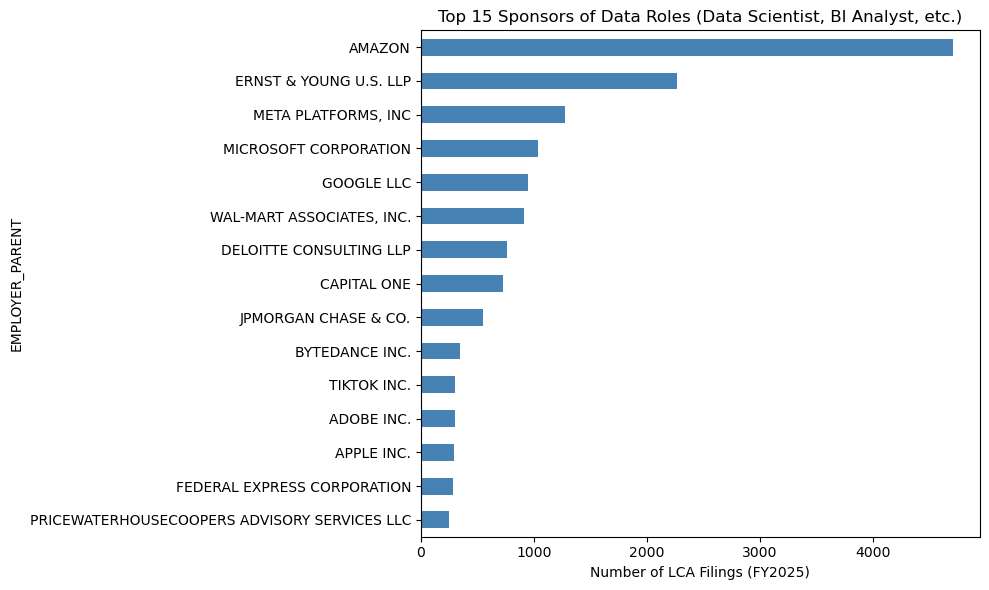

In [45]:
# Question 1 — visualized: Who sponsors the most data roles?
import matplotlib.pyplot as plt

top_15 = df_clean["EMPLOYER_PARENT"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_15.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Number of LCA Filings (FY2025)")
plt.title("Top 15 Sponsors of Data Roles (Data Scientist, BI Analyst, etc.)")
plt.tight_layout()
plt.savefig("../data/processed/top_sponsors.png", dpi=150)
plt.show()

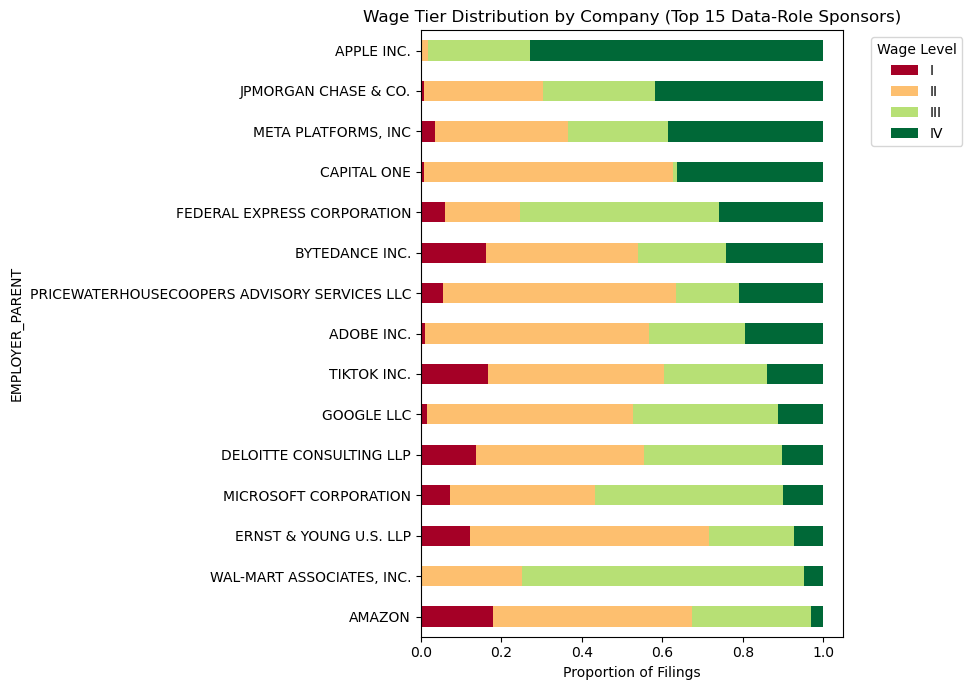

In [46]:
# Question 2 — visualized: Wage tier breakdown by company
# Recompute with NaN -> 0 fix
wage_level_by_company = (
    df_clean[df_clean["EMPLOYER_PARENT"].isin(top_15_companies)]
    .groupby("EMPLOYER_PARENT")["PW_WAGE_LEVEL"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# Reorder columns I -> IV for a sensible visual order
wage_level_by_company = wage_level_by_company[["I", "II", "III", "IV"]]

# Sort companies by Level IV share, so "best lottery odds" companies appear at the top
wage_level_by_company = wage_level_by_company.sort_values("IV", ascending=True)

wage_level_by_company.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 7),
    colormap="RdYlGn"  # red (Level I) -> green (Level IV), intuitive for "better odds"
)
plt.xlabel("Proportion of Filings")
plt.title("Wage Tier Distribution by Company (Top 15 Data-Role Sponsors)")
plt.legend(title="Wage Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../data/processed/wage_tier_by_company.png", dpi=150)
plt.show()

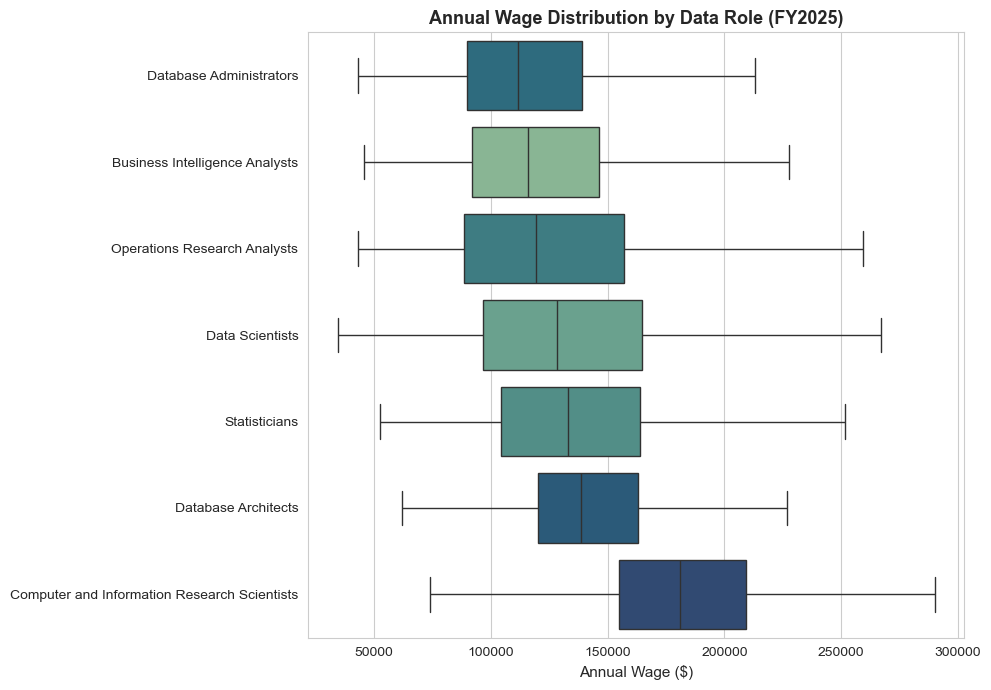

In [50]:
# Question 3: What's the median wage by role type?
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

sns.boxplot(
    data=df_clean,
    y="SOC_TITLE",
    x="ANNUAL_WAGE",
    order=role_order,
    showfliers=False,
    hue="SOC_TITLE",
    palette="crest",
    legend=False
)

plt.xlabel("Annual Wage ($)", fontsize=11)
plt.ylabel("")
plt.title("Annual Wage Distribution by Data Role (FY2025)", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig("../data/processed/wage_distribution_by_role.png", dpi=150, bbox_inches="tight")
plt.show()

FISCAL_QUARTER
Q1    10038
Q2    12545
Q3    25724
Q4    10794
Name: count, dtype: int64


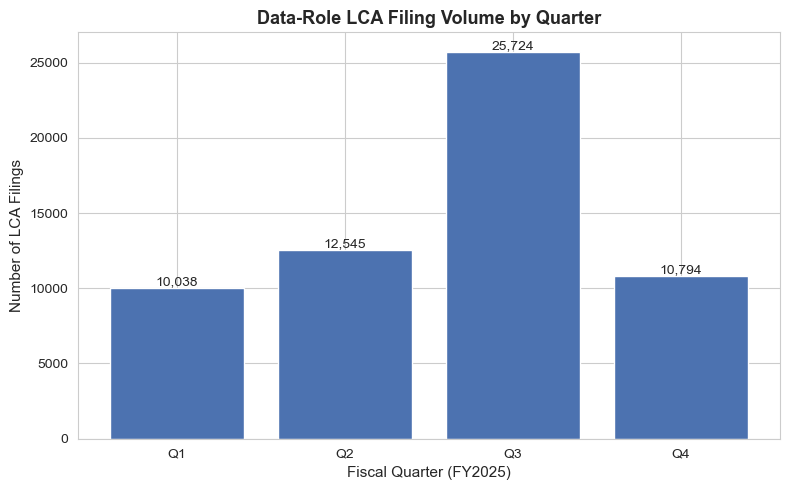

In [51]:
# Question 4: Does filing volume change over the year (seasonality)?
quarterly_counts = df_clean["FISCAL_QUARTER"].value_counts().sort_index()

print(quarterly_counts)

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

bars = plt.bar(quarterly_counts.index, quarterly_counts.values, color="#4C72B0")
plt.xlabel("Fiscal Quarter (FY2025)", fontsize=11)
plt.ylabel("Number of LCA Filings", fontsize=11)
plt.title("Data-Role LCA Filing Volume by Quarter", fontsize=13, weight="bold")

# Add value labels on top of each bar for clarity
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200, f"{int(height):,}",
              ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../data/processed/filings_by_quarter.png", dpi=150, bbox_inches="tight")
plt.show()

WORKSITE_STATE
CA    11613
TX     8364
NY     5986
WA     5383
NJ     3423
IL     2774
MA     2293
GA     2147
VA     2072
NC     2042
FL     1667
PA     1435
OH      907
MI      888
TN      807
Name: count, dtype: int64


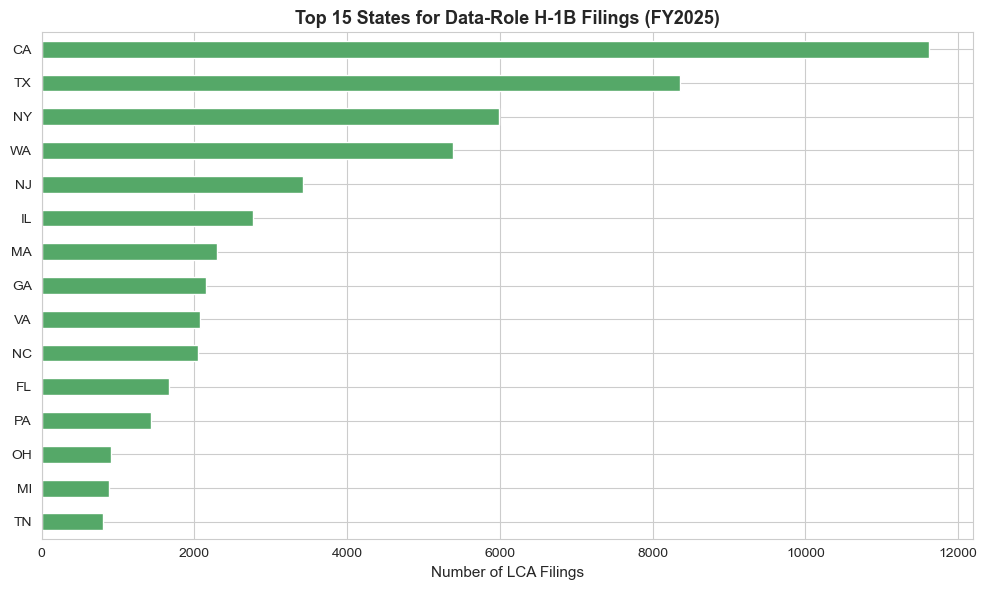

In [52]:
# Question 5: Where are data roles concentrated? (location)
top_states = df_clean["WORKSITE_STATE"].value_counts().head(15)

print(top_states)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

top_states.sort_values().plot(kind="barh", color="#55A868")
plt.xlabel("Number of LCA Filings", fontsize=11)
plt.ylabel("")
plt.title("Top 15 States for Data-Role H-1B Filings (FY2025)", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig("../data/processed/filings_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

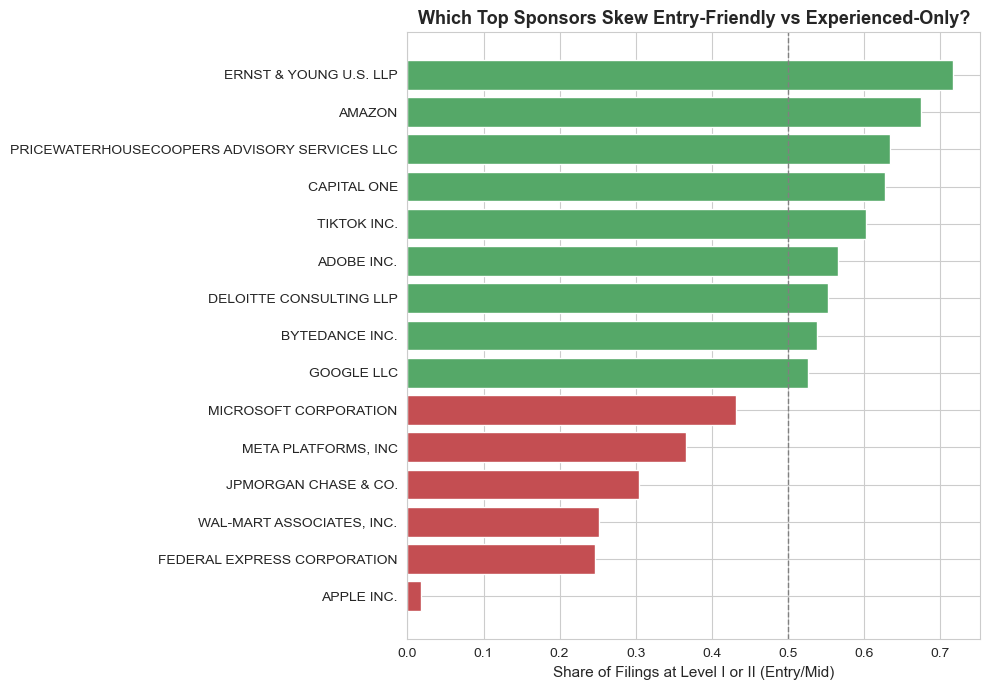

In [53]:
# Question 6: Which companies skew toward entry-level (I/II) vs experienced (III/IV) hiring?
# Reuse the same wage_level_by_company table, but rank by Level I+II share (entry/mid-friendly)
entry_friendly_score = wage_level_by_company["I"] + wage_level_by_company["II"]
entry_friendly_score = entry_friendly_score.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

colors = ["#C44E52" if v < 0.5 else "#55A868" for v in entry_friendly_score.values]
plt.barh(entry_friendly_score.index, entry_friendly_score.values, color=colors)

plt.axvline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Share of Filings at Level I or II (Entry/Mid)", fontsize=11)
plt.title("Which Top Sponsors Skew Entry-Friendly vs Experienced-Only?", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig("../data/processed/entry_friendly_companies.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
# ML STARTS HERE
for col in ["EMPLOYER_PARENT", "SOC_TITLE", "WORKSITE_STATE", "FULL_TIME_POSITION"]:
    print(f"{col}: {df_clean[col].nunique()} unique values")

EMPLOYER_PARENT: 13017 unique values
SOC_TITLE: 7 unique values
WORKSITE_STATE: 52 unique values
FULL_TIME_POSITION: 2 unique values


In [55]:
# Feature 1: how many total filings does this employer have? (captures company size/consistency)
employer_filing_counts = df_clean["EMPLOYER_PARENT"].value_counts()
df_clean["EMPLOYER_FILING_COUNT"] = df_clean["EMPLOYER_PARENT"].map(employer_filing_counts)

# Quick sanity check
df_clean[["EMPLOYER_PARENT", "EMPLOYER_FILING_COUNT"]].drop_duplicates().sort_values(
    "EMPLOYER_FILING_COUNT", ascending=False
).head(5)

,EMPLOYER_PARENT,EMPLOYER_FILING_COUNT
41,AMAZON,4714
288,ERNST & YOUNG U.S. LLP,2271
251,"META PLATFORMS, INC",1277
1448,MICROSOFT CORPORATION,1038
352,GOOGLE LLC,949


In [57]:
print(df_clean.columns.tolist())

['CASE_NUMBER', 'CASE_STATUS', 'VISA_CLASS', 'RECEIVED_DATE', 'DECISION_DATE', 'JOB_TITLE', 'SOC_CODE', 'SOC_TITLE', 'FULL_TIME_POSITION', 'EMPLOYER_NAME', 'EMPLOYER_STATE', 'NAICS_CODE', 'WORKSITE_CITY', 'WORKSITE_STATE', 'WAGE_RATE_OF_PAY_FROM', 'WAGE_RATE_OF_PAY_TO', 'WAGE_UNIT_OF_PAY', 'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'PW_WAGE_LEVEL', 'FISCAL_QUARTER', 'ANNUAL_WAGE', 'EMPLOYER_NAME_CLEAN', 'EMPLOYER_PARENT', 'EMPLOYER_FILING_COUNT']


In [58]:
df_clean["HAS_WAGE_LEVEL"] = df_clean["PW_WAGE_LEVEL"].notna()
print(df_clean["HAS_WAGE_LEVEL"].value_counts())

HAS_WAGE_LEVEL
True     55442
False     3659
Name: count, dtype: int64


In [59]:
df_model = df_clean[df_clean["HAS_WAGE_LEVEL"]].copy()

model_cols = ["SOC_TITLE", "WORKSITE_STATE", "FULL_TIME_POSITION", "EMPLOYER_FILING_COUNT", "PW_WAGE_LEVEL"]
df_model = df_model[model_cols]

print(df_model.shape)
df_model.head()

(55442, 5)


,SOC_TITLE,WORKSITE_STATE,FULL_TIME_POSITION,EMPLOYER_FILING_COUNT,PW_WAGE_LEVEL
32,Business Intelligence Analysts,MN,Y,25,II
39,Data Scientists,TX,Y,4,I
41,Statisticians,WA,Y,4714,III
71,Operations Research Analysts,IL,Y,9,IV
95,Database Administrators,NC,Y,1,I


In [60]:
# One-hot encode the categorical columns
df_model_encoded = pd.get_dummies(
    df_model,
    columns=["SOC_TITLE", "WORKSITE_STATE", "FULL_TIME_POSITION"],
    drop_first=True
)

print(df_model_encoded.shape)
df_model_encoded.head()

(55442, 60)


,EMPLOYER_FILING_COUNT,PW_WAGE_LEVEL,SOC_TITLE_Computer and Information Research Scientists,SOC_TITLE_Data Scientists,SOC_TITLE_Database Administrators,SOC_TITLE_Database Architects,SOC_TITLE_Operations Research Analysts,SOC_TITLE_Statisticians,WORKSITE_STATE_AL,WORKSITE_STATE_AR,...,WORKSITE_STATE_TN,WORKSITE_STATE_TX,WORKSITE_STATE_UT,WORKSITE_STATE_VA,WORKSITE_STATE_VT,WORKSITE_STATE_WA,WORKSITE_STATE_WI,WORKSITE_STATE_WV,WORKSITE_STATE_WY,FULL_TIME_POSITION_Y
32,25,II,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
39,4,I,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
41,4714,III,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
71,9,IV,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
95,1,I,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [61]:
X = df_model_encoded.drop(columns=["PW_WAGE_LEVEL"])
y = df_model_encoded["PW_WAGE_LEVEL"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\ny value counts:")
print(y.value_counts())

X shape: (55442, 59)
y shape: (55442,)

y value counts:
PW_WAGE_LEVEL
II     23334
III    12405
I      10284
IV      9419
Name: count, dtype: int64


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (44353, 59)
Test size: (11089, 59)


In [64]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [65]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {accuracy:.2%}\n")

print(classification_report(y_test, y_pred))

Overall accuracy: 43.31%

              precision    recall  f1-score   support

           I       0.59      0.05      0.08      2057
          II       0.43      0.96      0.59      4667
         III       0.52      0.08      0.14      2481
          IV       0.50      0.01      0.01      1884

    accuracy                           0.43     11089
   macro avg       0.51      0.27      0.21     11089
weighted avg       0.49      0.43      0.30     11089



In [66]:
baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Lazy baseline (always guess most common class): {baseline_accuracy:.2%}")

Lazy baseline (always guess most common class): 42.09%


In [67]:
# Rebuild the modeling dataset with additional features
model_cols_v2 = ["SOC_TITLE", "WORKSITE_STATE", "FULL_TIME_POSITION", 
                  "EMPLOYER_FILING_COUNT", "PREVAILING_WAGE", "NAICS_CODE", "PW_WAGE_LEVEL"]

df_model_v2 = df_clean[df_clean["HAS_WAGE_LEVEL"]][model_cols_v2].copy()

print(df_model_v2.shape)
print(df_model_v2["NAICS_CODE"].isna().sum(), "missing NAICS codes")

(55442, 7)
0 missing NAICS codes


In [68]:
print(df_model_v2["NAICS_CODE"].nunique(), "unique NAICS codes")
df_model_v2["NAICS_CODE"].value_counts().head(10)


1193 unique NAICS codes


NAICS_CODE
541511    10279
541512     2779
541211     2271
45411      2173
513210     1692
518210     1546
541611     1333
519290     1233
522110     1121
611310     1086
Name: count, dtype: int64

In [69]:
# Truncate to 2-digit NAICS sector (broad industry category)
df_model_v2["NAICS_SECTOR"] = df_model_v2["NAICS_CODE"].astype(str).str[:2]

print(df_model_v2["NAICS_SECTOR"].nunique(), "unique sectors")
df_model_v2["NAICS_SECTOR"].value_counts()

25 unique sectors


NAICS_SECTOR
54    24358
52     7382
51     7126
45     4910
33     2430
61     1281
62     1045
32     1003
42      914
44      815
56      797
55      713
48      461
49      361
31      355
53      329
81      240
22      230
72      197
23      147
92      119
71      103
21       87
11       30
-4        9
Name: count, dtype: int64

In [70]:
# Treat the malformed "-4" sector as a generic "Unknown" category
df_model_v2["NAICS_SECTOR"] = df_model_v2["NAICS_SECTOR"].replace("-4", "Unknown")

print(df_model_v2["NAICS_SECTOR"].value_counts().tail(5))

NAICS_SECTOR
92         119
71         103
21          87
11          30
Unknown      9
Name: count, dtype: int64


In [71]:
final_cols = ["SOC_TITLE", "WORKSITE_STATE", "FULL_TIME_POSITION", 
              "EMPLOYER_FILING_COUNT", "PREVAILING_WAGE", "NAICS_SECTOR", "PW_WAGE_LEVEL"]

df_model_v2 = df_model_v2[final_cols]

df_model_v2_encoded = pd.get_dummies(
    df_model_v2,
    columns=["SOC_TITLE", "WORKSITE_STATE", "FULL_TIME_POSITION", "NAICS_SECTOR"],
    drop_first=True
)

print(df_model_v2_encoded.shape)

(55442, 85)


In [72]:
X_v2 = df_model_v2_encoded.drop(columns=["PW_WAGE_LEVEL"])
y_v2 = df_model_v2_encoded["PW_WAGE_LEVEL"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model_v2.fit(X_train_v2, y_train_v2)

print("Model B trained.")

Model B trained.


In [73]:
y_pred_v2 = model_v2.predict(X_test_v2)

accuracy_v2 = accuracy_score(y_test_v2, y_pred_v2)
print(f"Model B overall accuracy: {accuracy_v2:.2%}")
print(f"(Model A was: 43.31%, baseline was: 42.09%)\n")

print(classification_report(y_test_v2, y_pred_v2))

Model B overall accuracy: 73.31%
(Model A was: 43.31%, baseline was: 42.09%)

              precision    recall  f1-score   support

           I       0.82      0.56      0.67      2057
          II       0.67      0.94      0.78      4667
         III       0.83      0.50      0.63      2481
          IV       0.82      0.72      0.77      1884

    accuracy                           0.73     11089
   macro avg       0.79      0.68      0.71     11089
weighted avg       0.76      0.73      0.72     11089



In [74]:
importances = pd.Series(model_v2.feature_importances_, index=X_v2.columns).sort_values(ascending=False)
importances.head(10)

PREVAILING_WAGE                           0.643854
EMPLOYER_FILING_COUNT                     0.094712
NAICS_SECTOR_54                           0.037518
SOC_TITLE_Operations Research Analysts    0.016905
WORKSITE_STATE_WA                         0.015358
SOC_TITLE_Database Administrators         0.015270
WORKSITE_STATE_CA                         0.014237
NAICS_SECTOR_45                           0.013696
NAICS_SECTOR_52                           0.011739
FULL_TIME_POSITION_Y                      0.011708
dtype: float64

In [75]:
!pip install xgboost --quiet

In [78]:
!pip install lightgbm --quiet

In [79]:
try:
    import xgboost
except ImportError:
    print("Need: !pip install xgboost --quiet")

try:
    import lightgbm
except ImportError:
    print("Need: !pip install lightgbm --quiet")

In [80]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

# XGBoost and LightGBM need numeric labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_v2)
y_test_enc = label_encoder.transform(y_test_v2)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "Gradient Boosting (sklearn)": GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(n_estimators=100, max_depth=6, random_state=42, verbose=-1),
}

results = []

for name, m in models.items():
    start = time.time()
    if name in ["XGBoost", "LightGBM"]:
        m.fit(X_train_v2, y_train_enc)
        preds = m.predict(X_test_v2)
        acc = accuracy_score(y_test_enc, preds)
    else:
        m.fit(X_train_v2, y_train_v2)
        preds = m.predict(X_test_v2)
        acc = accuracy_score(y_test_v2, preds)
    elapsed = time.time() - start
    results.append({"Model": name, "Accuracy": acc, "Train Time (s)": round(elapsed, 1)})
    print(f"{name}: {acc:.2%} ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\n", results_df)

Random Forest: 73.31% (1.0s)
Gradient Boosting (sklearn): 90.10% (15.7s)
XGBoost: 94.24% (0.7s)
LightGBM: 91.97% (0.5s)

                          Model  Accuracy  Train Time (s)
2                      XGBoost  0.942375             0.7
3                     LightGBM  0.919740             0.5
1  Gradient Boosting (sklearn)  0.900983            15.7
0                Random Forest  0.733069             1.0


In [81]:
xgb_final = models["XGBoost"]
importances_xgb = pd.Series(xgb_final.feature_importances_, index=X_v2.columns).sort_values(ascending=False)
importances_xgb.head(10)

WORKSITE_STATE_WA                                         0.058554
WORKSITE_STATE_CA                                         0.048661
PREVAILING_WAGE                                           0.044150
SOC_TITLE_Computer and Information Research Scientists    0.035769
WORKSITE_STATE_NJ                                         0.034641
SOC_TITLE_Database Administrators                         0.033879
WORKSITE_STATE_NY                                         0.032338
SOC_TITLE_Operations Research Analysts                    0.031808
WORKSITE_STATE_OH                                         0.028436
WORKSITE_STATE_TN                                         0.027815
dtype: float32

In [82]:
train_preds = xgb_final.predict(X_train_v2)
train_acc = accuracy_score(y_train_enc, train_preds)
print(f"XGBoost training accuracy: {train_acc:.2%}")
print(f"XGBoost test accuracy: 94.24%")

XGBoost training accuracy: 96.05%
XGBoost test accuracy: 94.24%


In [83]:
from sklearn.model_selection import cross_val_score

# Re-encode full y for cross-validation
y_v2_encoded = label_encoder.transform(y_v2)

cv_scores = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric="mlogloss"),
    X_v2, y_v2_encoded, cv=5, scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print(f"Mean: {cv_scores.mean():.2%}, Std: {cv_scores.std():.2%}")

Cross-validation scores: [0.94462981 0.94904861 0.938943   0.94687951 0.69462482]
Mean: 89.48%, Std: 10.02%


In [84]:
# Check distribution of small categories that could cause this instability
print("Smallest states by count:")
print(df_model_v2["WORKSITE_STATE"].value_counts().tail(10))

print("\nSmallest NAICS sectors by count:")
print(df_model_v2["NAICS_SECTOR"].value_counts().tail(10))

Smallest states by count:
WORKSITE_STATE
ME    20
WY    17
ND    16
SD    16
WV    13
VT    12
HI     9
PR     6
AK     3
MT     2
Name: count, dtype: int64

Smallest NAICS sectors by count:
NAICS_SECTOR
53         329
81         240
22         230
72         197
23         147
92         119
71         103
21          87
11          30
Unknown      9
Name: count, dtype: int64


In [85]:
# Group states with fewer than 50 filings into "OTHER"
state_counts = df_model_v2["WORKSITE_STATE"].value_counts()
rare_states = state_counts[state_counts < 50].index

df_model_v3 = df_model_v2.copy()
df_model_v3["WORKSITE_STATE"] = df_model_v3["WORKSITE_STATE"].apply(
    lambda x: "OTHER" if x in rare_states else x
)

print(df_model_v3["WORKSITE_STATE"].nunique(), "states after grouping (was 52)")
print(df_model_v3["WORKSITE_STATE"].value_counts().tail(10))

42 states after grouping (was 52)
WORKSITE_STATE
KS    132
AL    128
OK    123
IA    114
RI    113
NH    102
NE    101
ID     70
LA     60
NM     50
Name: count, dtype: int64


In [86]:
# Re-encode with the fixed state grouping
df_model_v3_encoded = pd.get_dummies(
    df_model_v3,
    columns=["SOC_TITLE", "WORKSITE_STATE", "FULL_TIME_POSITION", "NAICS_SECTOR"],
    drop_first=True
)

X_v3 = df_model_v3_encoded.drop(columns=["PW_WAGE_LEVEL"])
y_v3 = df_model_v3_encoded["PW_WAGE_LEVEL"]
y_v3_encoded = label_encoder.transform(y_v3)

print(X_v3.shape)

# Re-run cross-validation with the same XGBoost setup
cv_scores_v2 = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric="mlogloss"),
    X_v3, y_v3_encoded, cv=5, scoring="accuracy"
)

print("Cross-validation scores:", cv_scores_v2)
print(f"Mean: {cv_scores_v2.mean():.2%}, Std: {cv_scores_v2.std():.2%}")

(55442, 74)
Cross-validation scores: [0.94562179 0.94895843 0.938943   0.94823232 0.70589827]
Mean: 89.75%, Std: 9.59%


In [87]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=False)  # shuffle=False to match cross_val_score's default behavior

fold_num = 0
for train_idx, test_idx in skf.split(X_v3, y_v3_encoded):
    fold_num += 1
    if fold_num == 5:  # the problem fold
        X_fold_train, X_fold_test = X_v3.iloc[train_idx], X_v3.iloc[test_idx]
        y_fold_train, y_fold_test = y_v3_encoded[train_idx], y_v3_encoded[test_idx]
        print(f"Fold 5 — train size: {len(train_idx)}, test size: {len(test_idx)}")
        print("Test set label distribution:", pd.Series(y_fold_test).value_counts().sort_index())
        print("Train set label distribution:", pd.Series(y_fold_train).value_counts().sort_index())

Fold 5 — train size: 44354, test size: 11088
Test set label distribution: 0    2057
1    4666
2    2481
3    1884
Name: count, dtype: int64
Train set label distribution: 0     8227
1    18668
2     9924
3     7535
Name: count, dtype: int64


In [88]:
xgb_test = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric="mlogloss")
xgb_test.fit(X_fold_train, y_fold_train)
fold5_preds = xgb_test.predict(X_fold_test)
fold5_acc = accuracy_score(y_fold_test, fold5_preds)
print(f"Fold 5 accuracy: {fold5_acc:.2%}")

# Compare: what does the model predict vs actual, by class
print("\n", classification_report(y_fold_test, fold5_preds))

Fold 5 accuracy: 70.59%

               precision    recall  f1-score   support

           0       0.87      0.77      0.81      2057
           1       0.80      0.63      0.71      4666
           2       0.51      0.67      0.58      2481
           3       0.70      0.89      0.78      1884

    accuracy                           0.71     11088
   macro avg       0.72      0.74      0.72     11088
weighted avg       0.73      0.71      0.71     11088



In [89]:
# Compare which original states appear in fold 5's test set vs the full dataset
fold5_test_original = df_model_v3.iloc[test_idx]
print("Fold 5 test set state distribution:")
print(fold5_test_original["WORKSITE_STATE"].value_counts(normalize=True).head(10))

print("\nFull dataset state distribution:")
print(df_model_v3["WORKSITE_STATE"].value_counts(normalize=True).head(10))

Fold 5 test set state distribution:
WORKSITE_STATE
CA    0.172529
TX    0.159812
NY    0.104437
WA    0.087662
NJ    0.058351
IL    0.043741
MA    0.037969
NC    0.037338
GA    0.032738
FL    0.031926
Name: proportion, dtype: float64

Full dataset state distribution:
WORKSITE_STATE
CA    0.181000
TX    0.147019
NY    0.104073
WA    0.085459
NJ    0.058656
IL    0.048808
MA    0.039916
GA    0.037535
NC    0.034992
VA    0.034775
Name: proportion, dtype: float64


In [90]:
cv_scores_shuffled = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric="mlogloss"),
    X_v3, y_v3_encoded, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy"
)

print("Shuffled CV scores:", cv_scores_shuffled)
print(f"Mean: {cv_scores_shuffled.mean():.2%}, Std: {cv_scores_shuffled.std():.2%}")

Shuffled CV scores: [0.93840743 0.94571197 0.94471501 0.94417388 0.94534632]
Mean: 94.37%, Std: 0.27%


In [91]:
final_model = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric="mlogloss")
final_model.fit(X_train_v2, y_train_enc)  # using original train split from before, with state grouping baked into X_v2...

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [92]:
# Redo the train/test split using X_v3/y_v3 (rare states grouped into "OTHER")
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3_encoded, test_size=0.2, random_state=42, stratify=y_v3_encoded
)

final_model = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric="mlogloss")
final_model.fit(X_train_v3, y_train_v3)

final_preds = final_model.predict(X_test_v3)
final_accuracy = accuracy_score(y_test_v3, final_preds)

print(f"Final model test accuracy: {final_accuracy:.2%}")
print("\n", classification_report(y_test_v3, final_preds))

Final model test accuracy: 94.36%

               precision    recall  f1-score   support

           0       0.93      0.96      0.94      2057
           1       0.94      0.96      0.95      4667
           2       0.94      0.91      0.93      2481
           3       0.97      0.92      0.94      1884

    accuracy                           0.94     11089
   macro avg       0.95      0.94      0.94     11089
weighted avg       0.94      0.94      0.94     11089



In [93]:
import joblib

joblib.dump(final_model, "../data/processed/wage_level_model.pkl")
joblib.dump(X_v3.columns.tolist(), "../data/processed/model_features.pkl")
joblib.dump(label_encoder, "../data/processed/label_encoder.pkl")  # needed to convert predictions back to "I"/"II"/"III"/"IV"
joblib.dump(rare_states.tolist(), "../data/processed/rare_states.pkl")  # needed to replicate the "OTHER" grouping on new inputs later

print("Final model and all supporting files saved.")

Final model and all supporting files saved.
